In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [ ]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/worst_case/CMR/90-10-LBA/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

/tmp/ipykernel_109787/4227710710.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498.41463717
 1498.41463717 1498.41463717 1498.41463717 1498.41463717 1498

In [ ]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
df_grouped.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped[df_grouped.ne(0).any(axis=1)].index[-1]
df_grouped = df_grouped.loc[:last_non_zero_index]
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

             index  data_written_bytes  cumulative_gb
count  2361.000000         2361.000000    2361.000000
mean   1180.000000          555.154596     664.647889
std     681.706315          123.583346     364.947953
min       0.000000          157.522214       3.644512
25%     590.000000          483.662208     355.420827
50%    1180.000000          562.318243     673.204244
75%    1770.000000          634.091402     981.820916
max    2360.000000         3731.980747    1280.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               2361 non-null   int64  
 1   data_written_bytes  2361 non-null   float64
 2   cumulative_gb       2361 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 55.5 KB
None


In [ ]:
data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'


# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped[df_grouped['data_written_bytes'] < 50]

# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']

# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45


Average1: 458
Average2: 632


458.10538802138353
632.0865413103079


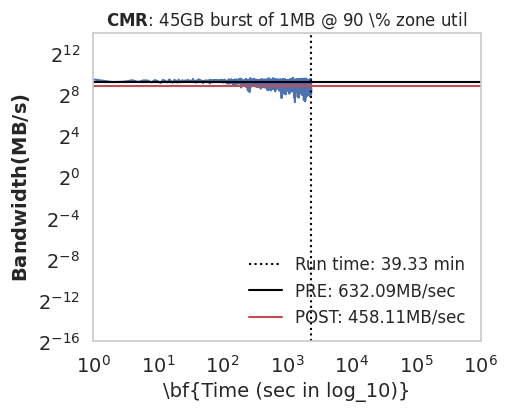

In [ ]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped)
plt.title(r"$\bf{CMR}$: 45GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'\bf{Time (sec in log_10)}', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/4K_90Util_9010_CMR_BW.pdf', bbox_inches='tight', format="pdf") 

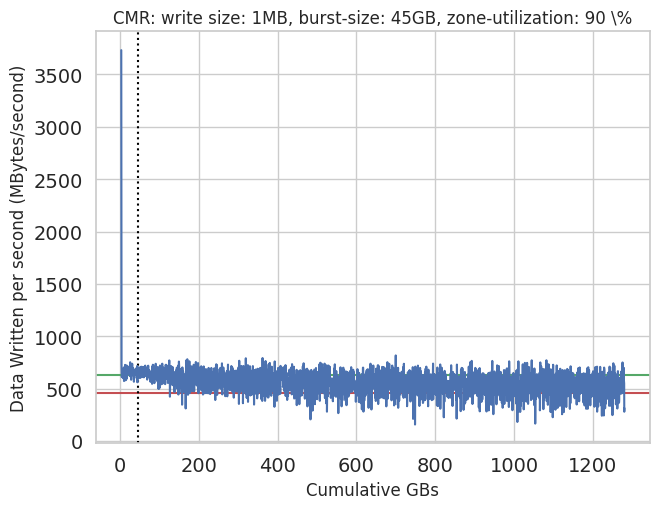

In [ ]:

# Plot vertical lines at x where y is higher than the threshold
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.axvline(x=first_cumulative_gb, color='black', linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

#plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 1MB, burst-size: 45GB, zone-utilization: 90 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_90Util_STL_CGBW.png', bbox_inches='tight')
plt.show()